In [161]:

import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
mpl.rcParams.update(mpl.rcParamsDefault)
from scipy.signal import savgol_filter
from scipy.optimize import curve_fit

In [162]:
savefigs=False

In [163]:
sig_mw=2.3925
Rs=10

In [164]:
def smooth(y, box_pts):
    box = np.ones(box_pts)/box_pts
    y_smooth = np.convolve(y, box, mode='same')
    return y_smooth


In [165]:
def gam_bulk(T,c0,c1,c2,c3):
    return(c0*(T**3)+c1*(T**2)+c2*T+c3)

In [166]:
overleafpath = "/Users/phxnw/Dropbox/Apps/Overleaf/Hydrophobic attraction between solutes/Figures/"

In [167]:
#First do attractive solute case

In [168]:

#basedir = f"/Users/phxnw/Dropbox/Hydrophobicity/density-fluct/MW_Sphere_pmf/metadynamics/Attractive_solute/Mary_potential/P0_Rs{Rs}/Test/"
basedir = f"/Users/phxnw/Dropbox/Hydrophobicity/density-fluct/MW_Sphere_pmf/metadynamics/Attractive_solute/Mary_potential/P0_Rs{Rs}/"
opdir = f"/Users/phxnw/Dropbox/Hydrophobicity/density-fluct/MW_Sphere_pmf/FigsData"

print("basedir =", basedir)


basedir = /Users/phxnw/Dropbox/Hydrophobicity/density-fluct/MW_Sphere_pmf/metadynamics/Attractive_solute/Mary_potential/P0_Rs10/


In [169]:
#!cd {basedir+"BIAS10-T300.0-P0.0-Rs10-D00.01"}; plumed sum_hills --hills HILLS
#!cd {basedir+"BIAS10-T300.0-P750.0-Rs10-D00.01"}; plumed sum_hills --hills HILLS
#!cd {basedir+"BIAS10-T300.0-P1500.0-Rs10-D00.01"}; plumed sum_hills --hills HILLS

 #!cd {basedir+"BIAS10-T400.0-P0.0-Rs10-D00.01"}; plumed sum_hills --hills HILLS
# !cd {basedir+"BIAS10-T300.0-P3000.0-Rs10-D00.01"}; plumed sum_hills --hills HILLS

# !cd {basedir+"BIAS10-T300.0-P0.0-Rs10-D00.8"}; plumed sum_hills --hills HILLS
#!cd {basedir+"BIAS10-T300.0-P0.0-Rs10-D00.4"}; plumed sum_hills --hills HILLS
# !cd {basedir+"BIAS10-T300.0-P0.0-Rs10-D01.0"}; plumed sum_hills --hills HILLS
#!cd {basedir+"BIAS10-T300.0-P0.0-Rs10-D01.1"}; plumed sum_hills --hills HILLS 
# !cd {basedir+"BIAS10-T300.0-P0.0-Rs10-D01.2"}; plumed sum_hills --hills HILLS
# !cd {basedir+"BIAS10-T300.0-P0.0-Rs10-D01.4"}; plumed sum_hills --hills HILLS

# !cd {basedir+"BIAS10-T425.0-P0.0-Rs10-D00.8"}; plumed sum_hills --hills HILLS
# !cd {basedir+"BIAS10-T425.0-P0.0-Rs10-D01.0"}; plumed sum_hills --hills HILLS
#!cd {basedir+"BIAS10-T425.0-P0.0-Rs10-D01.1"}; plumed sum_hills --hills HILLS
# !cd {basedir+"BIAS10-T425.0-P0.0-Rs10-D01.2"}; plumed sum_hills --hills HILLS

#!cd {basedir+"BIAS10-T360.0-P0.0-Rs10-D01.1"}; plumed sum_hills --hills HILLS

#!cd {basedir+"BIAS10-T300.0-P0.0-Rs4-D00.01"}; plumed sum_hills --hills HILLS
#!cd {basedir+"BIAS10-T300.0-P0.0-Rs6-D00.01"}; plumed sum_hills --hills HILLS
#!cd {basedir+"BIAS10-T300.0-P0.0-Rs7.5-D00.01"}; plumed sum_hills --hills HILLS
#!cd {basedir+"BIAS10-T300.0-P0.0-Rs9-D00.01"}; plumed sum_hills --hills HILLS

#!cd {basedir+"BIAS10-T300.0-P0.0-Rs5-D00.01"}; plumed sum_hills --hills HILLS
#!cd {basedir+"BIAS10-T300.0-P0.0-Rs5-D00.6"}; plumed sum_hills --hills HILLS
#!cd {basedir+"BIAS10-T300.0-P0.0-Rs5-D00.8"}; plumed sum_hills --hills HILLS
#!cd {basedir+"BIAS10-T300.0-P0.0-Rs5-D01.0"}; plumed sum_hills --hills HILLS

#!cd {basedir+"BIAS10-T300.0-P0.0-Rs3-D00.01"}; plumed sum_hills --hills HILLS
#!cd {basedir+"BIAS10-T300.0-P0.0-Rs3-D00.2"}; plumed sum_hills --hills HILLS



processing p=0.0, T=300.0, D0=0.01, Rs=10


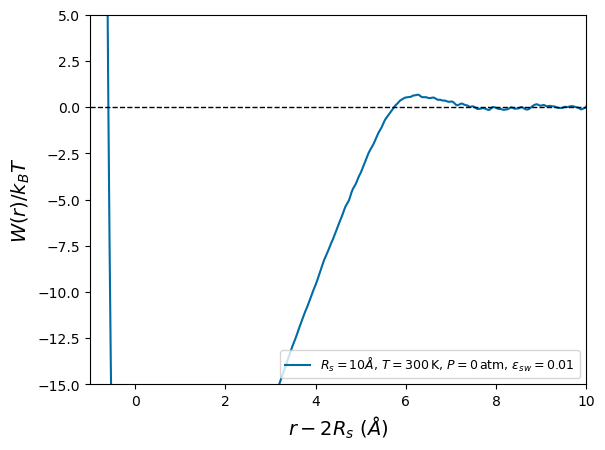

In [170]:


plt.style.use('tableau-colorblind10')

cases = [
    #   P     T     D0     Rs

#    (750.0, 300.0, 0.01,  10),
#    (1500.0, 300.0, 0.01,  10),
#    (3000.0, 300.0, 0.01,  10),


    
   (0.0, 300.0, 0.01,  10),
#    (0.0, 300.0, 0.40,   10),
#    (0.0, 300.0, 0.80,   10),
#     (0.0, 300.0, 1.00,   10),
#    (0.0, 300.0, 1.10,   10),
#    (0.0, 300.0, 1.20,   10),
#    (0.0, 300.0, 1.40,   10)

  #   (0.0, 360.0, 1.10,   10)
  #    (0.0, 400.0, 0.01,   10),
    
#    (0.0, 425.0, 1.20,   10),
  #     (0.0, 425.0, 1.00,   10),
 #  (0.0, 425.0, 0.80,   10),
#     (0.0, 300.0, 0.01, 9),
#    (0.0, 300.0, 0.01, 7.5),

 #   (0.0, 300.0, 0.01, 6),
    
 #    (0.0, 300.0, 0.01, 5),   
#    (0.0, 300.0, 0.60, 5),   
#   (0.0, 300.0, 0.80, 5), 
#    (0.0, 300.0, 1.00, 5) 
#       (0.0, 300.0, 0.01, 4),

#   (0.0, 300.0, 0.01,  3),   
#  (0.0, 300.0, 0.20,  3), 
]


bin_width=6
for P, T, D0, Rs in cases:
    print("processing p={P}, T={T}, D0={D0}, Rs={Rs}".format(P=P, T=T, D0=D0, Rs=Rs))
    kBT_kcal = 0.0019872041 * T
    data=np.loadtxt(basedir+"BIAS{}-T{}-P{}-Rs{}-D0{}/fes.dat".format(10,T,P,Rs,D0))
    rvals = data[:,0]
    F     = data[:,1]
    pmf_raw = (F / kBT_kcal) + 2.0*np.log(rvals)
    mask = (2*Rs+7 < rvals) & (rvals < 2*Rs+9)
    zero = pmf_raw[mask].mean()
    pot = smooth(pmf_raw - zero, bin_width)
    shift=2*Rs
    x = rvals - shift
    y = pot


    label = (
       r"$R_s={:.0f}\AA$, "
       r"$T={:.0f}\,\mathrm{{K}}$, "
       r"$P={:.0f}\,\mathrm{{atm}}$, "
       r"$\epsilon_{{sw}}={}$").format(Rs, T, P, D0)
    plt.plot(x,y,label = label)
    # save plotted dataset
    import os
    os.makedirs(opdir, exist_ok=True)
    outfile = os.path.join(opdir,f"pmf_T{T:.1f}_P{P:.1f}_Rs{Rs:.1f}_D0{D0:.2f}.dat")
    np.savetxt(outfile,np.column_stack((x, y)),header="r_minus_2Rs_A,    PMF_over_kBT")

plt.legend(loc = 'lower right',fontsize=9)
plt.plot(rvals,np.zeros_like(pot[:len(rvals)]),'--')
plt.xlim(-1,10)
 #plt.xlim(26.5,28)
plt.ylim(-15,5)
plt.ylim(top=5.0)



# compare with model
#A=1e-10
#shift=0
#Rs=10*A

# compare with model
# T=300
# JtokBT=1/(1.3806e-23*T)
# P=800                     # This is in atmospheres, but we convert to mu in J below.
# dmu=(P/1000.0)*1.5e-20  # in units of Joules
# drho=1.08e28             # Number density difference in m^-3

# gamma=0.066*drho/3.33e28  # in units of Jm^{-2}= 66 N/m with an ad-hoc correction factor based on the ratio of drho to it bulk value 
# l=0.8*A

# r = np.linspace(1.993*Rs, 2.01*(Rs+l))
# A300=JtokBT*Au(dmu, drho, gamma, Rs,r,l)
# V300=JtokBT*V0(dmu, drho, gamma, Rs,r,l)

# plt.plot(r/A-shift,A300+V300,'-', mfc="None")

# T=426
# JtokBT=1/(1.3806e-23*T)
# P=570                     # This is in atmospheres, but we convert to mu in J below.
# dmu=(P/1000.0)*1.5e-20  # in units of Joules
# drho=0.87e28             # Number density difference in m^-3

# gamma=0.066*drho/3.33e28  # in units of Jm^{-2}= 66 N/m with an ad-hoc correction factor based on the ratio of drho to it bulk value 
# l=1.35*A

# r = np.linspace(1.993*Rs, 2.01*(Rs+l))
# A300=JtokBT*Au(dmu, drho, gamma, Rs,r,l)
# V300=JtokBT*V0(dmu, drho, gamma, Rs,r,l)

# plt.plot(r/A-shift,A300+V300,'-', mfc="None")

plt.xlabel(r"$r-2R_s~$($\AA$)",fontsize=14)
plt.ylabel(r"$W(r)/k_BT$",fontsize=14)
plt.axhline(y=0, color='k', linestyle='--', linewidth=1)
if(savefigs):
    plt.savefig(overleafpath+"pmf_variousD0_T{:.0f}_Rs{:.0f}.pdf".format(T,Rs/A),format="pdf")

plt.show()



In [171]:
def leq(dmu, drho,  gamma, Rs ):
    return  20.2*A - np.log(dmu*drho+2*gamma/Rs)*A  # Check the units here, there are missing factors to make the terms dimensionless
#    return 1.4e-10

def V0(dmu, drho,  gamma, Rs,r,l ):
    return -np.pi/12 * (r**3-12*r*(Rs+l)**2 + 16 * (Rs+l)**3 ) *(dmu*drho+2*gamma/Rs)

def Au(dmu, drho,  gamma, Rs,r,l ):
    return 2*np.pi*( r*(Rs+l) - 2 * (Rs+l)**2) * gamma




In [172]:
def model_lsP(r,drho,l,P):
    A=1e-10
    T=300
    JtokBT=1/(1.3806e-23*T)
    Rs=10*A
    l=l*A
    r=r*A
    gamma=0.066*drho/3.33e28
    dmu=P*1.46e-23
    Volterm= -np.pi/12 * (r**3-12*r*(Rs+l)**2 + 16 * (Rs+l)**3 ) *(dmu*drho+2*gamma/Rs)
    #Volterm= -np.pi/12 * (r**3-12*r*(Rs+l)**2 + 16 * (Rs+l)**3 ) *(dmu*drho)
    Areaterm= 2*np.pi*( r*(Rs+l) - 2 * (Rs+l)**2) * gamma
    effpot=JtokBT*(Volterm+Areaterm)
    return effpot